# TFT — Daily Revenue Forecast (31-day horizon)

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List

from darts import TimeSeries
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler, StaticCovariatesTransformer
from darts.utils.likelihood_models import QuantileRegression
from darts.explainability import TFTExplainer

import torch
import torchmetrics
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.lr_monitor import LearningRateMonitor

from sklearn.preprocessing import MinMaxScaler, StandardScaler

## 1. Загрузка и подготовка данных

In [61]:
df = pd.read_csv("data/raw_sales.csv", parse_dates=["date"])
df = df.sort_values(["category", "date"]).reset_index(drop=True)
df.head()

,date,category,revenue
0,2023-03-29,MA002,3022078.84
1,2023-03-30,MA002,2700089.87
2,2023-03-31,MA002,3312120.00
3,2023-04-01,MA002,3845285.20
4,2023-04-02,MA002,2930282.59


In [62]:
# Полный календарь: заполняем пропуски revenue=0
all_dates = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
full_idx = pd.MultiIndex.from_product(
    [df["category"].unique(), all_dates], names=["category", "date"]
)
df = (
    df.set_index(["category", "date"])
    .reindex(full_idx, fill_value=0)
    .reset_index()
)
df["is_missing"] = (df["revenue"] == 0).astype(int)
print(f"Series: {df['category'].nunique()}, Date range: {df['date'].min()} – {df['date'].max()}")
print(f"Total rows: {len(df)}")

Series: 59, Date range: 2023-03-29 00:00:00 – 2026-03-28 00:00:00
Total rows: 64664


## 2. Формирование TimeSeries

In [63]:
# Целевой ряд: revenue по category
ts_target_list = TimeSeries.from_group_dataframe(
    df=df,
    group_cols="category",
    time_col="date",
    value_cols="revenue"
    # static_cols=["category"]
)
print(f"Total series: {len(ts_target_list)}")

Total series: 59


<Axes: xlabel='date'>

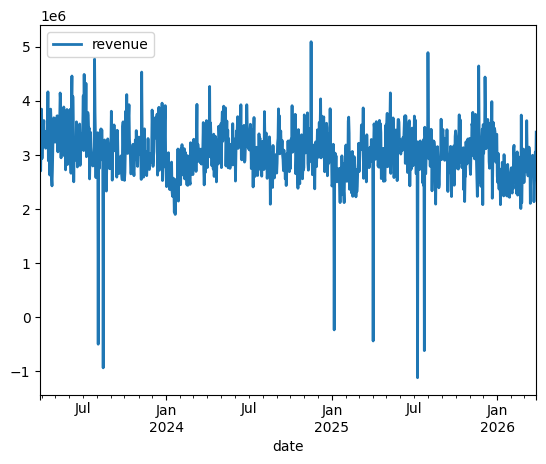

In [64]:
# Визуализация случайного ряда
ts_target_list[0].plot()

## 3. Нормализация

In [65]:
# Revenue: StandardScaler per-series
target_scaler = Scaler(scaler=StandardScaler(), global_fit=False)

# Static covariates: category → MinMaxScaler
static_scaler = StaticCovariatesTransformer(
    transformer_num=MinMaxScaler(feature_range=(0, 1)),
    cols_cat=["category"],
)

ts_target_list = target_scaler.fit_transform(ts_target_list)
ts_target_list = static_scaler.fit_transform(ts_target_list)

## 4. Разделение на train / val / test

In [66]:
# Параметры из spec
input_len = 90    # encoder
output_len = 31   # decoder / horizon
window_len = input_len + output_len  # 121

# Границы: test=31 день, val>=121 день (window_len), остальное — train
max_date = df["date"].max()
test_start = max_date - pd.Timedelta(days=30)
val_start = test_start - pd.Timedelta(days=121)  # val >= window_len

print(f"Train: start – {val_start}")
print(f"Val:   {val_start} – {test_start}  ({(test_start - val_start).days} дней)")
print(f"Test:  {test_start} – {max_date + pd.Timedelta(days=1)}  (31 день)")
print(f"Min series length needed: {window_len}")

Train: start – 2025-10-28 00:00:00
Val:   2025-10-28 00:00:00 – 2026-02-26 00:00:00  (121 дней)
Test:  2026-02-26 00:00:00 – 2026-03-29 00:00:00  (31 день)
Min series length needed: 121


In [67]:
def series_splitter(series_list: List[TimeSeries]):
    train, val, test = [], [], []
    for series in tqdm(series_list):
        # Darts slicing: [start, end) — end не включается
        test_s = series[test_start:]
        if len(test_s) > 0:
            test.append(test_s)
        
        val_s = series[val_start:test_start]
        if len(val_s) >= window_len:
            val.append(val_s)
        
        train_s = series[:val_start]
        if len(train_s) >= window_len:
            train.append(train_s)
    
    print(f"  Dropped: {len(series_list)-len(train)} train, {len(series_list)-len(val)} val, {len(series_list)-len(test)} test")
    return train, val, test

In [68]:
ts_train, ts_val, ts_test = series_splitter(ts_target_list)
print(f"Train: {len(ts_train)}, Val: {len(ts_val)}, Test: {len(ts_test)}")

100%|██████████| 59/59 [00:00<00:00, 2291.93it/s]

  Dropped: 0 train, 0 val, 0 test
Train: 59, Val: 59, Test: 59


## 5. Модель TFT

In [69]:
# Embedding для category
n_categories = df["category"].nunique()
static_cat_embedding_sizes = {"category": n_categories}

In [70]:
# Календарные признаки
encoders = {
    "cyclic": {"future": ["day", "day_of_year", "day_of_week", "month"]},
}

In [71]:
adam_kwargs = {"lr": 1e-3, "weight_decay": 1e-4}
lr_scheduler_kwargs = {"mode": "min", "factor": 0.5, "patience": 3, "min_lr": 1e-6}
early_stopping_kwargs = {"monitor": "val_loss", "patience": 5, "min_delta": 1e-4}

In [72]:
tft_model = TFTModel(
    model_name="tft_revenue",
    input_chunk_length=input_len,
    output_chunk_length=output_len,
    batch_size=64,
    n_epochs=5,
    force_reset=True,
    use_static_covariates=True,
    categorical_embedding_sizes=static_cat_embedding_sizes,
    add_encoders=encoders,
    hidden_size=64,
    lstm_layers=2,
    num_attention_heads=4,
    full_attention=True,
    hidden_continuous_size=16,
    work_dir="./logs",
    save_checkpoints=True,
    log_tensorboard=True,
    show_warnings=True,
    likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9]),
    torch_metrics=torchmetrics.WeightedMeanAbsolutePercentageError(),
    optimizer_cls=torch.optim.Adam,
    optimizer_kwargs=adam_kwargs,
    lr_scheduler_cls=torch.optim.lr_scheduler.ReduceLROnPlateau,
    lr_scheduler_kwargs=lr_scheduler_kwargs,
    pl_trainer_kwargs={
        "log_every_n_steps": 10,
        "callbacks": [
            EarlyStopping(**early_stopping_kwargs),
            LearningRateMonitor(logging_interval="epoch"),
        ]
    },
)

In [73]:
# Обучение
tft_model.fit(
    series=ts_train,
    val_series=ts_val,
    verbose=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train | 0    
1  | val_metrics                       | MetricCollection                 | 0      | train | 0    
2  | input_embeddings                  | _MultiEmbedding                  | 944    | train | 0    
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 192    | train | 0    
4  | encoder_vsn                       | _Varia

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

d:\VS_project\tft_monthly_remainder_forecast\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


d:\VS_project\tft_monthly_remainder_forecast\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 4: 100%|██████████| 761/761 [02:51<00:00,  4.43it/s, v_num=logs, train_loss=0.499, val_loss=0.379, val_WeightedMeanAbsolutePercentageError=0.635, train_WeightedMeanAbsolutePercentageError=0.887]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 761/761 [02:51<00:00,  4.43it/s, v_num=logs, train_loss=0.499, val_loss=0.379, val_WeightedMeanAbsolutePercentageError=0.635, train_WeightedMeanAbsolutePercentageError=0.887]


TFTModel(output_chunk_shift=0, hidden_size=64, lstm_layers=2, num_attention_heads=4, full_attention=True, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=16, categorical_embedding_sizes={'category': 59}, add_relative_index=False, skip_interpolation=False, loss_fn=None, likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9], prior_strength=1.0), norm_type=LayerNorm, use_static_covariates=True, model_name=tft_revenue, input_chunk_length=90, output_chunk_length=31, batch_size=64, n_epochs=5, force_reset=True, add_encoders={'cyclic': {'future': ['day', 'day_of_year', 'day_of_week', 'month']}}, work_dir=./logs, save_checkpoints=True, log_tensorboard=True, show_warnings=True, torch_metrics=WeightedMeanAbsolutePercentageError(), optimizer_cls=<class 'torch.optim.adam.Adam'>, optimizer_kwargs={'lr': 0.001, 'weight_decay': 0.0001}, lr_scheduler_cls=<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, lr_scheduler_kwargs={'mode': 'min', 'factor': 0.5, 'patience': 3, 'min

## 6. Прогноз и обратное преобразование

In [74]:
# Прогноз: подаём полные train-серии (нужна история >= input_len)
# Модель предскажет n=31 шага вперёд от конца каждой train-серии
tft_preds_scaled = tft_model.predict(
    n=output_len,
    series=ts_train,
    verbose=True,
    num_samples=500,
)
tft_preds = target_scaler.inverse_transform(tft_preds_scaled)

# Для оценки на test используем historical_forecasts (backtest на test-периоде)
tft_backtest = tft_model.historical_forecasts(
    series=ts_target_list,
    start=test_start,
    forecast_horizon=output_len,
    stride=1,
    retrain=False,
    verbose=True,
    num_samples=500,
)
tft_backtest = target_scaler.inverse_transform(tft_backtest)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\VS_project\tft_monthly_remainder_forecast\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:37<00:00,  0.03it/s]


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [ ]:
# Визуализация: backtest на test-периоде
# Берём первый backcast (последний forecast horizon)
last_fc = tft_backtest[0][-output_len:]  # последний горизонт прогноза
actual = ts_target_list[0][last_fc.start_time():last_fc.end_time() + pd.Timedelta(days=1)]

last_fc.plot(central_quantile=0.5, low_quantile=0.1, high_quantile=0.9)
actual.plot(label="actual")

In [ ]:
# SMAPE / WAPE на test-периоде (backtest)
def compute_smape(actual, pred):
    return 200 * np.mean(np.abs(pred - actual) / (np.abs(actual) + np.abs(pred)))

def compute_wape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(np.abs(actual)) * 100

for i in range(min(5, len(tft_backtest))):
    # Последний forecast horizon для каждой серии
    fc = tft_backtest[i][-output_len:]
    actual = ts_target_list[i][fc.start_time():fc.end_time() + pd.Timedelta(days=1)]
    pred = fc.quantile_timeseries(quantile=0.5)
    print(f"Series {i}: SMAPE={compute_smape(actual.values(), pred.values()):.2f}%, WAPE={compute_wape(actual.values(), pred.values()):.2f}%")

## 7. Интерпретация (TFTExplainer)

In [ ]:
explainer = TFTExplainer(
    tft_model,
    background_series=ts_train[0],
)
explainability_result = explainer.explain()

In [ ]:
# Variable Selection
explainer.plot_variable_selection(explainability_result)

In [ ]:
# Attention: усреднённый по времени
explainer.plot_attention(explainability_result, plot_type="time")

In [ ]:
# Attention: тепловая карта
explainer.plot_attention(explainability_result, plot_type="heatmap")